In [1]:
import numpy as np              # load numerical module
import matplotlib.pyplot as plt # load plotting module
import astropy.io.fits as fits  # load FITS module


## Relative readings:
- Handbook of CCD Astronomy Ch 3-4
- Astropy offers ready packages for a lot of the things we will see here, e.g.,:
    - https://ccdproc.readthedocs.io/en/latest/
    - https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/00-00-Preface.html 

## CCDs:
- Reading CCDs takes time (remember how they are read?)
- Often we can focus on windows/ subarrays of the CCD for our science observation
    - ensure the target is in the right part of the array
    - much faster readout (e.g., instead of having to read a 2048x2048 pixels of the CCD we focus on 512 pixel rows)
    - can observe brighter sources as faster readout allows us to not saturate pixels (e.g. JWST NIRSpec BOTS at 512x32 pixels )
    

| Sub 2             | Sub 1              |
| ---------------------- | ---------------------- |
| ![s1](target_subarray_2.png) | ![s1](target_subarray_1_bots.png) |

    (ETC calculation for a brown dwarf target; notice how different subarrays and reading modes allows to avoid saturation --in most bands)

## For getting our corrected image we need:
- QE differences were multiplied, so divide them out
- Dark current was added, so subtract it
- Bias voltage was added, so subtract it
- Basic formula:
$$ C=\frac{R-B-D}{F} $$
$C$ = corrected image, $R$ = raw image, $B$ = bias image, $D$ = dark image, $F$ = flat field


## Bias:

- Bias or zero images allow measuring the zero noise level of the CCD 
    - For an unexposed pixel, the value for zero collected $e^-$ will translate into a mean value with a small distribution about zero
    - To avoid negative numbers in the output image, CCD electronics are set up to provide a positive offset value for each accumulated image. This offset value, the mean “zero” level, is called the **bias level**.
        - typical bias level might be a value of 400 ADU (per pixel)
            - for a gain of 10 e−/ADU, equals 4000 electrons
            - large, but historically temporal drifts in CCD electronics due to age, temperature, or poor stability in the electronics, and higher read noise values, necessitated such levels
        - can be time variable; long periods though
            
- Evaluate the bias or zero noise level $\rightarrow$ take bias frames
   - take observations w/o exposure to light (shutter closed), for $t_\mathrm{int} = 0.000$ seconds. 
   - simply a readout of the unexposed CCD pixels through the on-chip electronics/ A/D converter/ to the PC $\rightarrow$ producing a 2D bias or zero image
   - we see any 2D structure that may exist in the CCD bias level
       - typically low level signal and stable with time
       
   - when using bias frames for calibration, best to work with an average or median frame composed of many (10 or more) individual bias images (Gilliland, 1992). 
       - eliminate CR, read noise variations, and random fluctuations, which are part of any single bias frame.
       
       
- Producing a histogram of a typical averaged bias frame gives Gaussian distribution
    - the mean level of this distribution gives the bias level offset for the CCD
    - width is related to the read noise of the CCD $$\rm{FWHM} = \frac{\rm{read_{-}noise}}{\mathrm{Gain}}$$

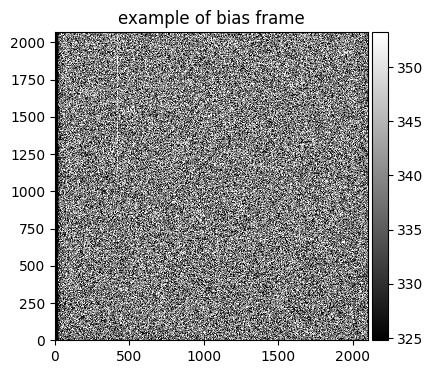

In [9]:
## by Yan Fernandez for AST 4762/5765.
#----------------------------------------------------------------------------
#This program demonstrates some basic things about FITS files, and
#in particular shows some particulars about bias frames, and
#about fitting Gaussians and polynomials.
#----------------------------------------------------------------------------
#import numpy as np
#import math
#import matplotlib.pyplot as plt
from scipy import special
from scipy import stats
from scipy.stats import chi2
#import sys
#----for reading in and writing out FITS files:
#import astropy
#from astropy import io
#from astropy.io import fits
#----for doing some fitting
from astropy import modeling
#from numpy import polynomial
#import copy
#----------------------------------------------------------------------------
#we'll be using histograms, so define the usual
#bin boundary generator function.
def getbinbounds(bw, arraymin, arraymax):
    intmin = np.floor(arraymin)
    intmax = np.ceil(arraymax)
    howmanybins = (intmax - intmin)/bw
    howmanybins = round(howmanybins)
    usethesebins = np.linspace(intmin, intmax, howmanybins+1)
    return usethesebins
#----------------------------------------------------------------------------
# let's look at a bias frame.
# read it in:

filbias = 'examplebias.fits'

#with fits.open(filbias) as biasimg:
#    biasdata = biasimg[0].data
#    biashdr = biasimg[0].header

#update TK since we don't need headers:
biasdata =  fits.getdata( filbias)

#show it.
quickmn = np.median(biasdata)
quicksg = np.std(biasdata)
nsl = -0.2
nsu = 0.2

plt.figure( figsize = ( 6,4 ) ) # figure 1
im1 = plt.imshow(biasdata, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im1,fraction=0.045, pad=0.01)

dm= plt.title("example of bias frame")



Check the sizes of these two arrays:
65535 65536
Now recheck -- did you reformat the array correctly?
65535


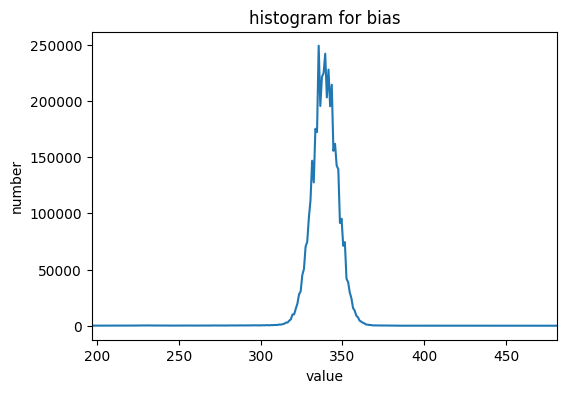

In [10]:
#check histogram of the bias.
#note that here Yan uses numpy's hist routine, but astropy and matplotlib
#have their own versions: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html 
#https://docs.astropy.org/en/stable/api/astropy.stats.histogram.html

binwid = 1.0
usethesebins = getbinbounds(binwid, np.min(biasdata), np.max(biasdata))
resuhist = np.histogram(biasdata, bins=usethesebins)
histvals_b = resuhist[0]
histbins_b = resuhist[1]



print("Check the sizes of these two arrays:")
print(histvals_b.size, histbins_b.size)
histbins_b = (histbins_b[1:] + histbins_b[0:histbins_b.size-1])/2.

# so that they have the same number of elements.
print("Now recheck -- did you reformat the array correctly?")
print(histbins_b.size)

plt.figure( figsize = ( 6,4 ) ) # figure 2
plt.plot(histbins_b, histvals_b)
plt.xlabel("value")
plt.ylabel("number")
plt.xlim(np.median(biasdata)-2.0*np.std(biasdata), \
np.median(biasdata)+2.0*np.std(biasdata))
dm = plt.title("histogram for bias")



best fitting gaussian for bias frame:
ampl 227835.0, mu 339.3, sigma 7.51
compare to the mediam: 339.0


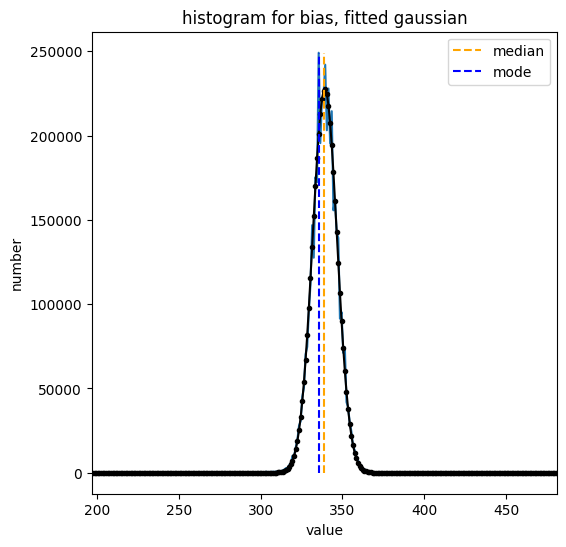

In [11]:
#----------------------------------------------------------------------------
# fit a Gaussian to that bias's histogram.
#invoke the fitting package:
fitter = modeling.fitting.LevMarLSQFitter()
#call up the Gaussian fitting routine, and give it some
#guesses at the right answer to help it.
model = modeling.models.Gaussian1D(amplitude=np.max(histvals_b), 
                                   mean=np.median(biasdata), stddev=np.std(biasdata))
#now actually do the fitting!
fitted_model = fitter(model, histbins_b, histvals_b)
#answers for the best-fitting gaussian:
bestamp = fitted_model.amplitude[0]
bestmn = fitted_model.mean[0]
bestsg = fitted_model.stddev[0]
print("best fitting gaussian for bias frame:")
print("ampl %8.1f, mu %5.1f, sigma %4.2f" % (bestamp, bestmn, bestsg))
print("compare to the mediam: %5.1f" % (np.median(biasdata)))

#now plot it up.
plt.figure( figsize = ( 6,6 ) ) # figure 3
plt.plot(histbins_b, histvals_b)
plt.plot(histbins_b, fitted_model(histbins_b), color='black')
plt.plot(histbins_b, fitted_model(histbins_b), '.', color='black')
plt.plot([np.median(biasdata),np.median(biasdata)], 
         [0,np.max(histvals_b)],'--', color='orange', label='median')

#plot the median for comparison.
#plot the mode also for comparison - it's different
mostfreq = np.where(histvals_b == np.max(histvals_b))
mostfreq = mostfreq[0][0]
plt.plot([histbins_b[mostfreq],histbins_b[mostfreq]], 
         [0,np.max(histvals_b)],'--', color='blue', label='mode')
plt.xlabel("value")
plt.ylabel("number")
plt.xlim(np.median(biasdata)-2.0*np.std(biasdata), 
         np.median(biasdata)+2.0*np.std(biasdata))
plt.title("histogram for bias, fitted gaussian")
dm = plt.legend(loc='upper right')


 
best fitting gaussian for bias frame when limiting the fit:
ampl 227546.1, mu 339.2, sigma 7.61


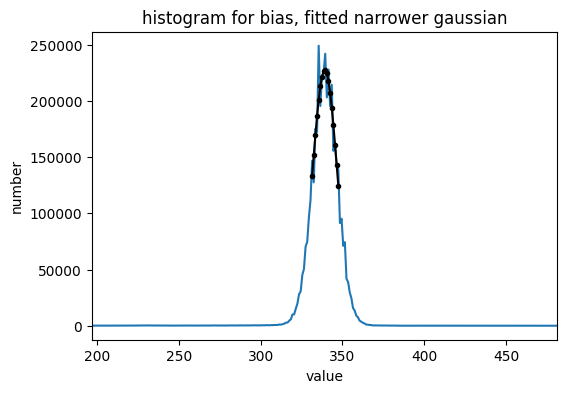

In [12]:
#----------------------------------------------------------------------------
#that gaussian fit was for the entire histogram --- yet that's
#not really ideal, since it means a bunch of wing points in the
#plot could be influencing the answer. Better is to just try to
#fits a gaussian near the peak itself, using only the histogram
#points near the peak.
#
#This is a judgement call, but let's say we want to fit the
#gaussian with points that are at least half the peak.
toinclude = np.where( histvals_b >= 0.5*np.max(histvals_b) )
toinclude = toinclude[0] #convert from tuple to array
ltdhistbins = histbins_b[toinclude]
ltdhistvals = histvals_b[toinclude]
#refit
fitted_model2 = fitter(model, ltdhistbins, ltdhistvals)
bestamp2 = fitted_model2.amplitude[0]
bestmn2 = fitted_model2.mean[0]
bestsg2 = fitted_model2.stddev[0]
print(" ")
print("best fitting gaussian for bias frame when limiting the fit:")
print("ampl %8.1f, mu %5.1f, sigma %4.2f" % (bestamp2, bestmn2, bestsg2))
#plot this
plt.figure( figsize = (6,4 )) # figure 4
plt.plot(histbins_b, histvals_b)
plt.plot(ltdhistbins, fitted_model(ltdhistbins), color='black')
plt.plot(ltdhistbins, fitted_model(ltdhistbins), '.', color='black')
plt.xlabel("value")
plt.ylabel("number")
plt.xlim(np.median(biasdata)-2.0*np.std(biasdata), 
         np.median(biasdata)+2.0*np.std(biasdata))
dm = plt.title("histogram for bias, fitted narrower gaussian")



parabola coefficients: 
 -1.50e+03 1.02e+06 -1.73e+08 
location of max: 339.3 


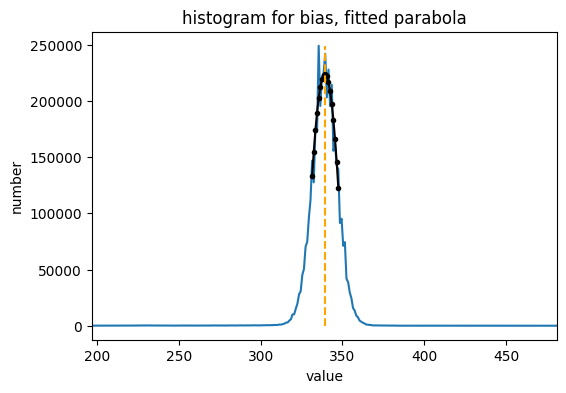

In [13]:
#----------------------------------------------------------------------------
#but another option is that you can just fit a parabola!
fitnearpeak = np.polyfit( ltdhistbins, ltdhistvals, 2)
fittedparab = np.polyval( fitnearpeak, ltdhistbins)
#fit is to y = ax^2 + bx + c.
#fitnearpeak[0] = a
#fitnearpeak[1] = b
#fitnearpeak[2] = c
#location of max is at x = -b/2a
locofmax = -1.0 * fitnearpeak[1] / (2.0 * fitnearpeak[0])
print("parabola coefficients: ")
print(" %7.2e %7.2e %7.2e " %(fitnearpeak[0], fitnearpeak[1], fitnearpeak[2]))
print("location of max: %5.1f " % (locofmax))
#plot this
plt.figure( figsize = ( 6,4 ) ) # figure 5
plt.plot(histbins_b, histvals_b)
plt.plot(ltdhistbins, fittedparab, color='black')
plt.plot(ltdhistbins, fittedparab, '.', color='black')
plt.plot([locofmax,locofmax],[0,np.max(histvals_b)],'--',color='orange')
plt.xlabel("value")
plt.ylabel("number")
plt.xlim(np.median(biasdata)-2.0*np.std(biasdata), 
         np.median(biasdata)+2.0*np.std(biasdata))
dm = plt.title("histogram for bias, fitted parabola")



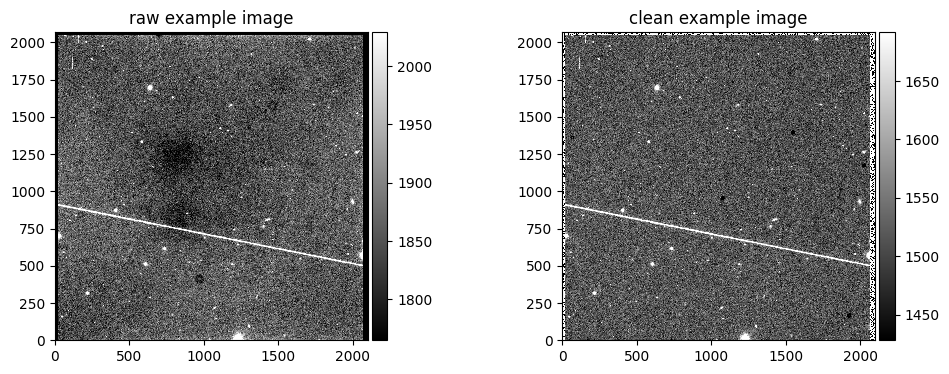

In [14]:
#Show a very quick example of how well the method works.
#just use 1 bias and 1 flat, don't try to be fancy.
#Can use the existing file as example bias. this is not
#the best way to do it but it will at least show that the method
#should clean things up well!
filflat = 'exampleflat.fits'
filtarg = 'examplerawdata2.fits'

#for Yan's reference:
#exampleflat.fits = nt2.023.fits
#examplerawdata2.fits = nt2.112.fits

#with fits.open(filflat) as flatimg:
#    flatdata = flatimg[0].data
#    flathdr = flatimg[0].header
#with fits.open(filtarg) as targimg:
#    targdata = targimg[0].data
#    targhdr = targimg[0].header

#update TK since we don't need headers:
flatdata =  fits.getdata( filflat ) 
targdata =  fits.getdata( filtarg )

flattouse = flatdata - biasdata
flattouse = flattouse / np.median(flattouse)
#find pixels that have zero, replace with median of whole frame.
whzero = np.where(flattouse == 0.0)
whzerox = whzero[0]
whzeroy = whzero[1]
flattouse[whzerox,whzeroy] = np.median(flattouse)
#here is the big equation!
cleandata = (targdata - biasdata) / flattouse
#show the before (raw) and after (clean) images so you can compare.
quickmn = np.median(targdata)
quicksg = np.std(targdata)
nsl = -0.1
msu = 0.2

fig,ax = plt.subplots(1,2, figsize = ( 12,4 ) ) # figure 6 and 7 
im1 = ax[0].imshow(targdata, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
ax[0].set_title("raw example image")
fig.colorbar(im1, ax=ax[0],fraction=0.04, pad=0.01)

quickmn = np.median(cleandata)

im2 = ax[1].imshow(cleandata, interpolation='none', origin='lower',
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
ax[1].set_title("clean example image")
dm = fig.colorbar(im2, ax=ax[1], fraction=0.04, pad=0.01)


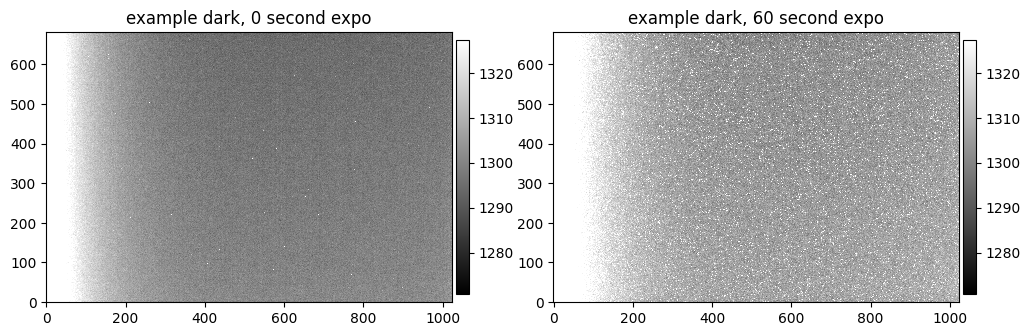

In [15]:
# check out some darks, just for fun. These are
# from the camera we had at Robinson Observatory, which we ran at about -5 deg C.
# these two darks were taken at 0 and 60 second exposures, respectively. Note that this is cold, 
# but not nearly cold enough to suppress all the dark current. A professional telescope will 
# have a CCD camera that runs at more like -100oC by using liquid nitrogen and very small dark current.

# The code here shows you two dark current frames. You obtain such frames by keeping 
# the shutter closed but letting the camera expose for some amount of time. 
# So the only electrons that get accumulated are those from the bias and from 
# the dark current. In the case of the first frame, where the exposure time is zero 
# seconds, that is basically equivalent to a bias frame so there's essentially no dark 
# current. The second frame however has an exposure time of 60 seconds, so there 
# are 60 seconds during which the pixels can collect some thermally-generated photons. 
# You can see the difference in the two images when they are displayed with the same 
# color stretch. The second image is a bit lighter because the pixels have collected 
# some dark current.
dark0sec = 'exampledark1.fits'

#with fits.open(dark0sec) as dark0:
#    data0 = dark0[0].data
#    hdr0 = dark0[0].header

#update TK since we don't need header:
#flatdata =  fits.getdata( dark0sec ).data 
    
dark60sec = 'exampledark2.fits'
#with fits.open(dark60sec) as dark60:
#    data60 = dark60[0].data
#    hdr60 = dark60[0].header

#update TK since we don't need header:
data0 =  fits.getdata( dark0sec )
data60 =  fits.getdata( dark60sec )
   
    
quickmn = np.median(data0)
quicksg = np.std(data0)
nsl = -2.5
nsu = 2.5 

fig,ax = plt.subplots(1,2, figsize = ( 12,4 ) )# figure 8 and 9 
im1 = ax[0].imshow(data0, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
ax[0].set_title("example dark, 0 second expo")
fig.colorbar(im1, ax=ax[0],fraction=0.03, pad=0.01)


im2 = ax[1].imshow(data60, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
ax[1].set_title("example dark, 60 second expo")
dm = fig.colorbar(im2, ax=ax[1],fraction=0.03, pad=0.01)



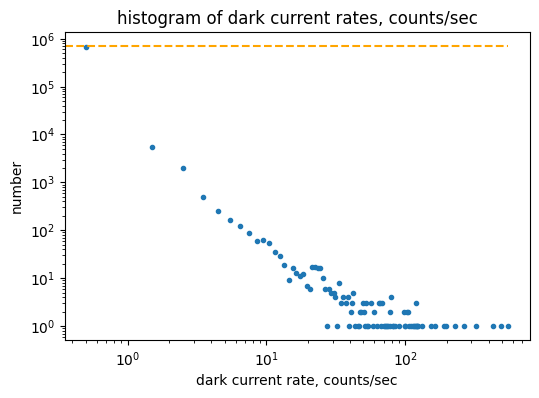

In [16]:

#----------------------------------------------------------------------------
#now calculate some dark current rates.
darkrate = (data60 - data0)/60. # units of counts per second, 60 sec expo.
#make a histogram of such rates.
binwid = 1.0
usethesebins = getbinbounds(binwid, np.min(darkrate), np.max(darkrate))
resuhist = np.histogram(darkrate, bins=usethesebins)
histvals_d = resuhist[0]
histbins_d = resuhist[1]
histbins_d = (histbins_d[1:] + histbins_d[0:histbins_d.size-1])/2.
# so that they have the same number of elements.
#make a histogram of these --- but it's different than what
#we've done earlier. This is a log-log histogram, plus I'm plotting
#dots instead of linked line segments.

plt.figure( figsize = ( 6,4 ) ) # figure 10
plt.plot(histbins_d, histvals_d, '.')
plt.plot([np.min(histbins_d),np.max(histbins_d)], 
         [data60.size,data60.size], '--', color='orange')
plt.xlabel("dark current rate, counts/sec")
plt.ylabel("number")
plt.yscale("log")
plt.xscale("log")
dm = plt.title("histogram of dark current rates, counts/sec")

#----------------------------------------------------------------------------
#end of program


## Flats (flat fields):

### In CCD each pixel has slightly different gain or QE value compared to neighbors. To flatten the relative response for each pixel to the incoming radiation, obtain flat field image and use to perform this calibration. 
- ideally, use uniform illumination of every pixel by a light source of identical spectral response to that of object
    - flat field should be spatially and spectrally flat $\rightarrow$ divide obs. by flat $\rightarrow$ get rid of pixel-to-pixel variations from science image
    - hard to get perfect though: 
        - uniform illumination needs to be in ppm 
        - would need light source with SED comparble to target
        - sky flat ideal but would need >> $t_\mathrm{int}\rightarrow$ end up with compromise 
    
   
<br>

- For imaging applications: obtain a flat field image by illuminating the inside of the telescope dome (or a screen mounted on the inside of the dome) with a light source $\rightarrow$ point the telescope at the bright spot on the dome 
    - take few relatively short exposures so as not to saturate the CCD $\rightarrow$ average to get master flat field
    - repeat for every filter you want to use
    
- Observatories often have mounted a flat field screen on the inside of each dome painted with special paints to reflect all wavs as uniformly as possible. Observatories' instrument user manuals discuss the various methods of obtaining flats. See, e.g.,: https://www2.keck.hawaii.edu/inst/common/DomeFlats.html; https://sites.astro.caltech.edu/palomar/observer/200inchResources/pharocookbook.html#flats 
    - flats of illuminated dome/dome screen == dome flats
    - observations of the twilight or night sky == sky flats
    
- Space telescopes give flats from lab measurements
<br>
    
- for most cases a 'good enough' flat is good enough

## Median Combination:
 
- Can use median combination to make flats, darks, biases, skies
    - Sigma-clipping from HW5 is even better, given enough images
- If sky varies *and* you are making skies, add indented *normalized* median combination steps
    - Take many dithered images
      - Subtract dark frame (cold shutter, "closed" filter)
      - Divide each frame by its median (median is now 1, may use median region rather than full frame) $\rightarrow$ all flats will be equally important/variation in sky illumination will not affect weight of frame to overall median
    - Loop over pixel positions
    - Find median of all images at each pixel position
    
- Astronomical sources, cosmic rays, bad pixels rejected!  Noise reduced!
  - Save as normalized median
  - Subtract normalized median from dark-subtracted, normalized images
  - Multiply each resulting image by the median it was divided by


In [30]:
# make 250x250 image of dark noise (here each pixel modeled from Gaussian 
np.random.seed(18)
# with mean 4 and sigma 1):

dark1 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )
#plt.imshow(dark1, cmap= 'gray')

In [31]:
#repeat 5 times:
dark2 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )
dark3 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )
dark4 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )
dark5 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )
dark6 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )

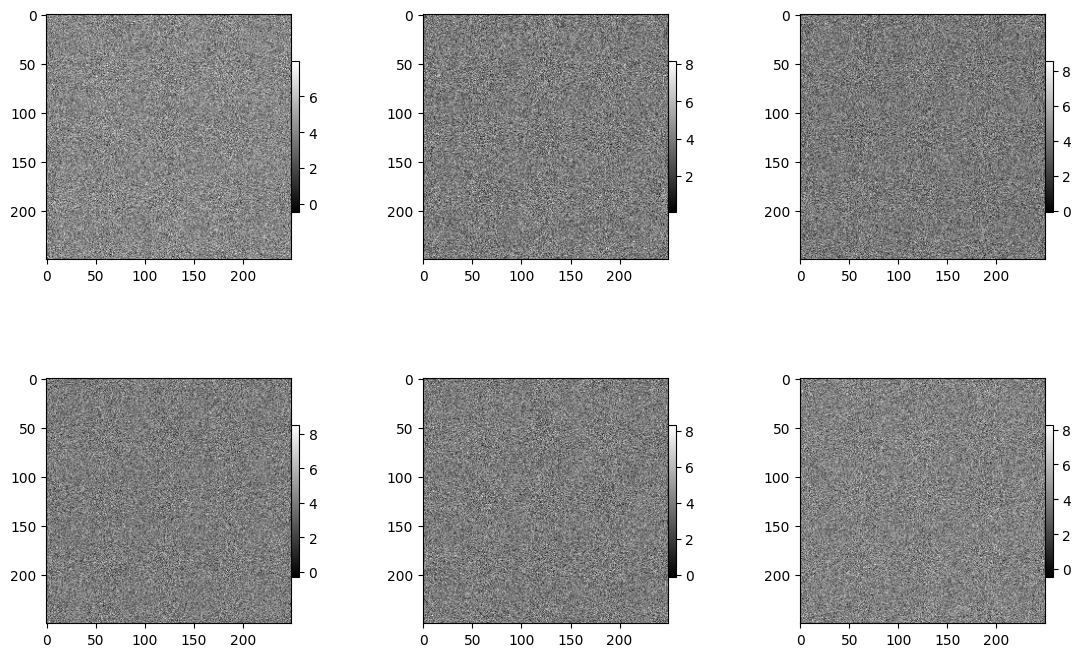

In [33]:
#let's see them all:

fig,( (ax1,ax2, ax3), (ax4,ax5,ax6) ) = plt.subplots( 2, 3, figsize = (12, 8) )
im1 = ax1.imshow( dark1,cmap= 'gray' )
fig.colorbar(im1, ax=ax1,fraction=0.03, pad=0.0)
im2 = ax2.imshow( dark2,cmap= 'gray' )
fig.colorbar(im2, ax=ax2,fraction=0.03, pad=0.0)
im3 = ax3.imshow( dark3,cmap= 'gray' )
fig.colorbar(im3, ax=ax3,fraction=0.03, pad=0.0)
im4 = ax4.imshow( dark4,cmap= 'gray' )
fig.colorbar(im4, ax=ax4,fraction=0.03, pad=0.0)
im5 = ax5.imshow( dark5,cmap= 'gray' )
fig.colorbar(im5, ax=ax5,fraction=0.03, pad=0.0)
im6 = ax6.imshow( dark6,cmap= 'gray' )
fig.colorbar(im6, ax=ax6,fraction=0.03, pad=0.0)
fig.tight_layout(pad=5.0)

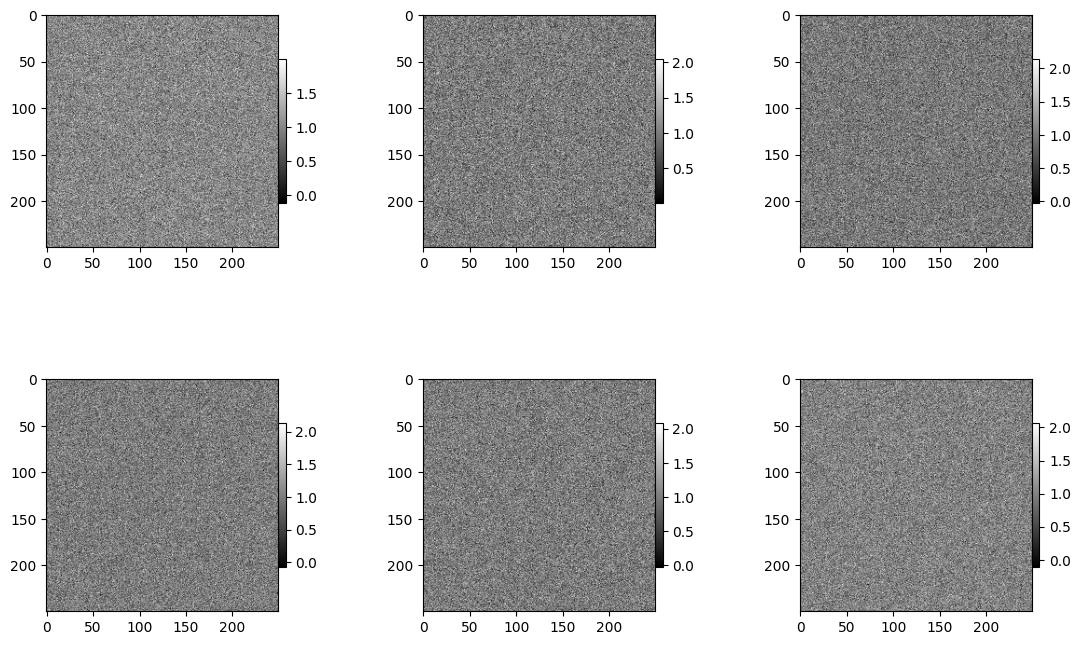

In [37]:
#divide each one by median:
# what happens if we skip this or not?
med_1 = 1
if med_1 == 1:
    dark1med = dark1/np.median( dark1 )
    dark2med = dark2/np.median( dark2 )
    dark3med = dark3/np.median( dark3 )
    dark4med = dark4/np.median( dark4 )
    dark5med = dark5/np.median( dark5 )
    dark6med = dark6/np.median( dark6 )
else:
    dark1med = dark1
    dark2med = dark2
    dark3med = dark3
    dark4med = dark4
    dark5med = dark5
    dark6med = dark5
    
fig,( (ax1,ax2, ax3), (ax4,ax5,ax6) ) = plt.subplots( 2, 3, figsize = (12, 8) )
im1 = ax1.imshow( dark1med,cmap= 'gray' )
fig.colorbar(im1, ax=ax1,fraction=0.03, pad=0.0)
im2 = ax2.imshow( dark2med,cmap= 'gray' )
fig.colorbar(im2, ax=ax2,fraction=0.03, pad=0.0)
im3 = ax3.imshow( dark3med,cmap= 'gray' )
fig.colorbar(im3, ax=ax3,fraction=0.03, pad=0.0)
im4 = ax4.imshow( dark4med,cmap= 'gray' )
fig.colorbar(im4, ax=ax4,fraction=0.03, pad=0.0)
im5 = ax5.imshow( dark5med,cmap= 'gray' )
fig.colorbar(im5, ax=ax5,fraction=0.03, pad=0.0)
im6 = ax6.imshow( dark6med,cmap= 'gray' )
fig.colorbar(im6, ax=ax6,fraction=0.03, pad=0.0)
fig.tight_layout(pad=5.0)



In [38]:
#median combine on 0 axis:
dark_med = np.median( 
    np.array([ dark1med,dark2med,dark3med,dark4med,
              dark5med,dark6med ]), axis=0, keepdims= True )

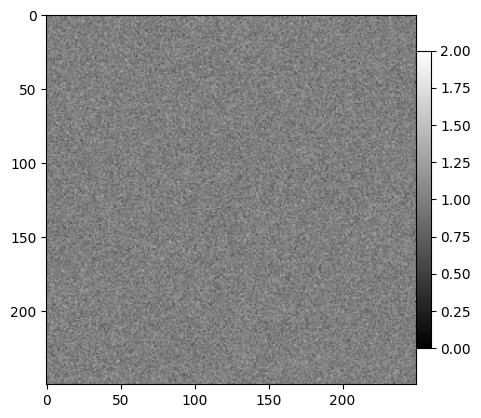

In [39]:
imcomb = plt.imshow( dark_med[0] , cmap='gray', vmin = 0, vmax = 2)
dm = plt.colorbar( imcomb,fraction=0.03, pad=0.0)

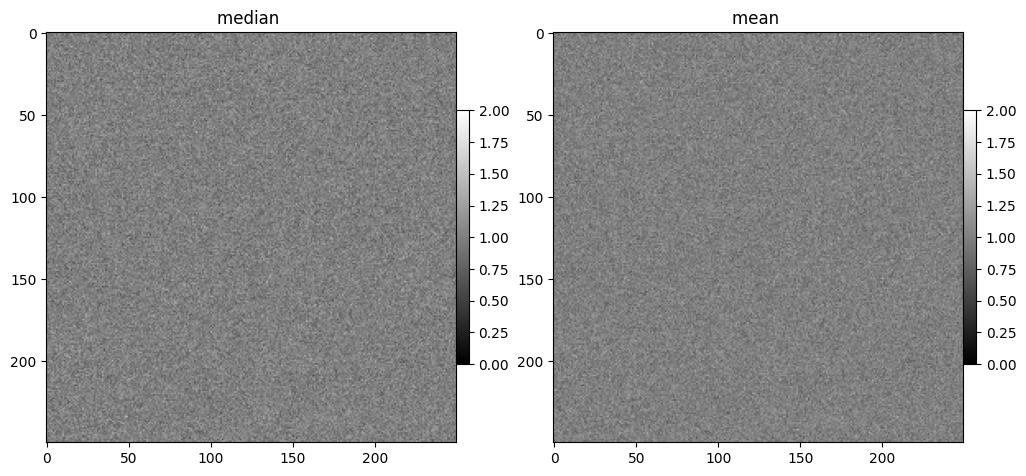

In [40]:
#what if instead of median we use mean ?

dark_mean = np.mean( 
    np.array([ dark1med,dark2med,dark3med,dark4med,
              dark5med,dark6med ]), axis=0, keepdims= True )


fig,ax = plt.subplots(1, 2, figsize = (12, 10 ) )

imcomb = ax[0].imshow( dark_med[0] , cmap='gray', vmin = 0, vmax = 2)
ax[0].set_title( 'median ')
dm = fig.colorbar( imcomb, ax=ax[0], fraction=0.03, pad=0.0)

imcomb_mean = ax[1].imshow( dark_mean[0] , cmap='gray', vmin = 0, vmax = 2)
ax[1].set_title( 'mean ')
dm = fig.colorbar( imcomb_mean, ax=ax[1], fraction=0.03, pad=0.0)

## Cleaning and Producing Sky Flats: 
- $I_{\rm d}$ (dark current) significant, as are thermal effects
- images of uniform sources of light
- Must subtract low-light and high-light with same integration time




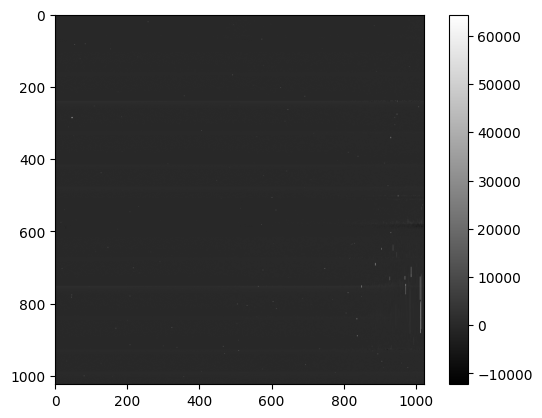

In [41]:
im = fits.getdata('09medcomb/dark_13s_5_raw.fits')
pim = plt.imshow(im,cmap = 'gray')
plt.colorbar(pim)

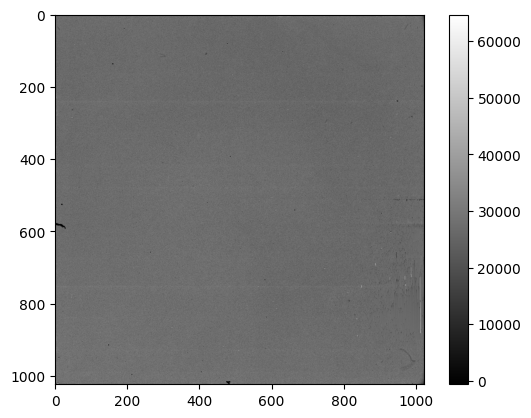

In [42]:
im = fits.getdata('09medcomb/k_lampon_1_raw.fits')
pim = plt.imshow(im,cmap = 'gray')
plt.colorbar(pim)

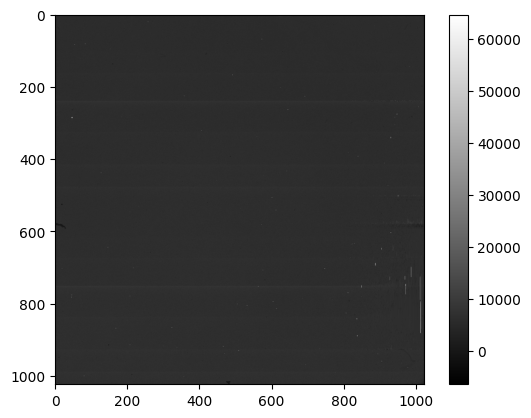

In [43]:
im = fits.getdata('09medcomb/k_lampoff_1_raw.fits')
pim = plt.imshow(im,cmap = 'gray')
plt.colorbar(pim)

### Make your flats:
- Method 1:
 - Use image of screen with IR lamp on minus same with lamp off
 - Take many exposures (eliminate cosmic rays, build $S/N$)
 - Take many exposures with lamp off, same int time
 - Median-combine lamp-on and lamp-off frames separately
 - Subtract the lamp-off median frame from the lamp-on median frame
 - Divide (normalize) by median of a large region in the middle of the frame so values ~1

<br>

- Method 2:
 - Sky (except stars) in early dawn may be "more flat"
     - But, need just right light levels: planning!
 - Park telescope so stars whiz through and don't burn in
 - Take many exposures at two different light levels
 - Median-combine, subtract, and divide as above
 - Star streaks should disappear in median combination (or too few frames)

### 1. In-class assignment (70 min) :  
- Read FITS file "flat.0005bsub.fits". This is a flat-field image (i.e. an image that lets us assess the non-uniformities in the detector's sensitivity). It has already had the bias level subtracted. Your goal is to find the mode, since that's what would be used later on to normalize this image. 

    - A. Read in the FITS file with the appropriate command. 
    - B. Make a histogram with matplotlib or numpy's "histogram" routine using a bin width of 5. This gives you a 1-D array of pixel values and a 1-D array of frequencies. The pixel values array will have 1 more element than the frequencies array, so you should correct for that.
    - C. Find the peak of this histogram. Your answer should be near a pixel value of 42800. Fitting the entire histogram is unnecessary, since we really only want the peak. So grab out a part of each of the two arrays that correspond to pixel values within say 250 of the peak. 
        - Added for clarity: this isn't asking to use ±250 index numbers from the location of the peak, it's literally ±250 numbers from the location of the peak. So it should be approximately 42400 to 43100.
    - D. Make a plot of just this part of the histogram. 
    - E. You should be able to tell by inspection of that plot that neither a Gaussian nor a parabola would give an adequate fit. The histogram simply doesn't have a shape like those functions. So a better option is a third-order polynomial, a cubic. 
        - You can either code your own polynomial funct using scipy optimization or use numpy's *polyfit* (https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) and *polyval* (https://numpy.org/doc/stable/reference/generated/numpy.polyval.html#numpy.polyval) functions to find and plot the best-fitting cubic polynomial.
    - F. What is the pixel value that corresponds to the peak of that best-fitting polynomial?
    - G. Repeat the plot from part E, but this time also plot the best-ftting cubic polynomial on top of the histogram. And this time, save this plot. Does the polynomial do a good job of tracing out the histogram?
    
From here, you would normalize the flat field by the answer you get for part G, then do this for all the flat-fields, and then combine them all into a master flat.

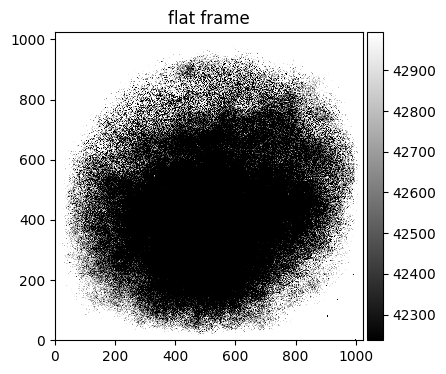

In [52]:
# A
flat = fits.getdata("flat.0005bsub.fits")

#show it.
quickmn = np.median(flat)
quicksg = np.std(flat)
nsl = -0.2
nsu = 0.2

plt.figure( figsize = ( 6,4 ) ) # figure 1
im1 = plt.imshow(flat, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im1,fraction=0.045, pad=0.01)

dm= plt.title("flat frame")

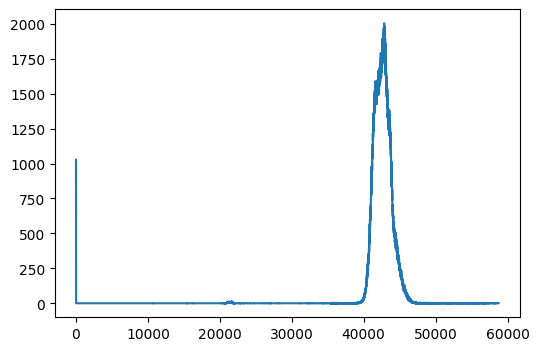

Check the sizes of these two arrays:
11755 11756
Now recheck -- did you reformat the array correctly?
11755


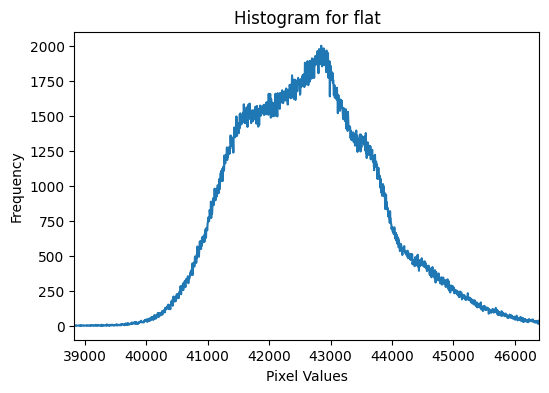

In [56]:
# B

# Karalidi version
binwidth = 5.0
usethesebins = getbinbounds(binwidth, np.min(flat), np.max(flat))
histvals, histbins = np.histogram(flat, bins=usethesebins)

plt.figure( figsize = ( 6,4 ) )
plt.plot(histbins[1:], histvals)
plt.show()

# Copy from above
binwidth = 5.0
usethesebins = getbinbounds(binwidth, np.min(flat), np.max(flat))
resuhist = np.histogram(flat, bins=usethesebins)
flatfreq = resuhist[0]
flatvals = resuhist[1]

print("Check the sizes of these two arrays:")
print(flatfreq.size, flatvals.size)

# They don't have same size so correct
flatvals = (flatvals[1:] + flatvals[0:flatvals.size-1])/2.
print("Now recheck -- did you reformat the array correctly?")
print(flatvals.size)

plt.figure( figsize = ( 6,4 ) )
plt.plot(flatvals, flatfreq)
plt.xlabel("Pixel Values")
plt.ylabel("Frequency")
plt.xlim(np.median(flat)-2.0*np.std(flat), \
np.median(flat)+2.0*np.std(flat))
dm = plt.title("Histogram for flat")

In [72]:
# C

flat_max_index = np.argmax(histvals)
print(flat_max_index)
flat_max = histbins[flat_max_index]
print(flat_max)

8569
42845.727


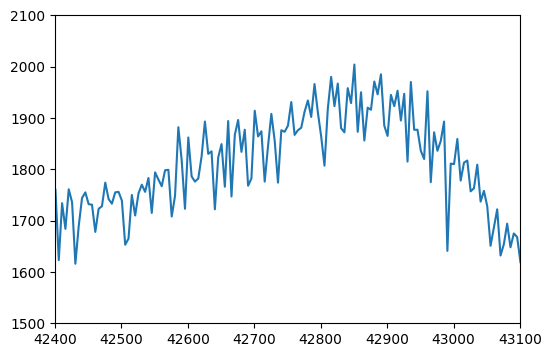

In [75]:
# D

plt.figure( figsize = ( 6,4 ) )
plt.plot(histbins[1:], histvals)
plt.ylim(1500, 2100)
plt.xlim(42400, 43100)
plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_33368\598715782.py:7: RankWarning: Polyfit may be poorly conditioned
  fitnearpeak = np.polyfit( histbins_fits, histbins_vals, 3)


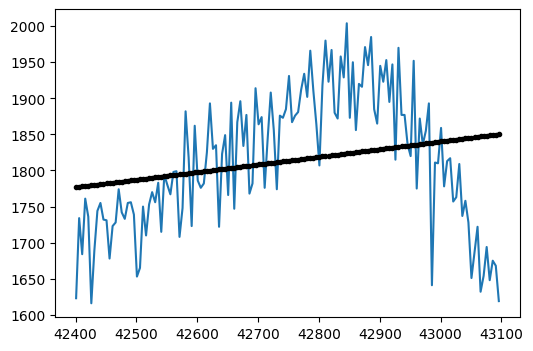

In [ ]:
# E

histbins_fits = histbins[np.where((histbins > 42400) & (histbins < 43100))]
histbins_vals = histvals[np.where((histbins > 42400) & (histbins < 43100))]


fitnearpeak = np.polyfit( histbins_fits, histbins_vals, 3)
fittedparab = np.polyval( fitnearpeak, histbins_fits)


plt.figure( figsize = ( 6,4 ) )
plt.plot(histbins_fits, histbins_vals)
plt.plot(histbins_fits, fittedparab, '.', color='black')
plt.show()


In [99]:
# F

# TO find the peak
fittedmax_index = np.argmax(fittedparab)
fittedmax = histbins_fits[fittedmax_index]
print(fittedmax)


43095.73


### Let's visualize one more flat. Read in FITS file *examplerawdata.fits*, which contains a (sky) flat field. 

In [2]:
#- - - - - - - - - - - - - -
#basic display:
filnm     = 'examplerawdata.fits'
flat_data = fits.getdata( filnm ).data

### Let's scale the colors using the median and std to get a better idea of what we see:

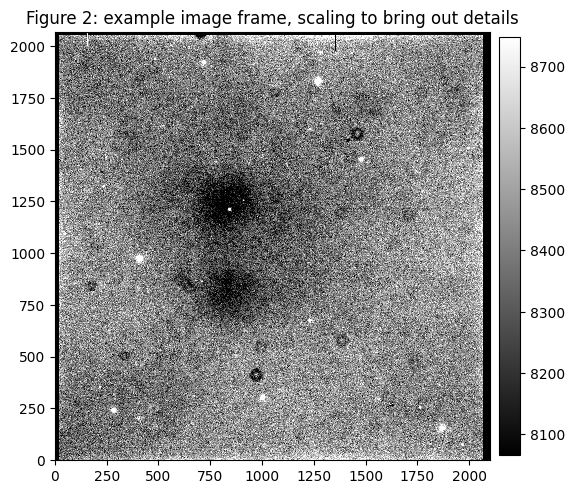

In [3]:
quickmn = np.median( flat_data )
quicksg = np.std( flat_data )

ns = 0.2

plt.figure( figsize = (6, 6) ) # figure 2
d2 = plt.imshow( flat_data, interpolation='none', origin='lower', 
           vmin=quickmn - ns*quicksg, vmax=quickmn + ns*quicksg, 
           cmap='gray')
plt.colorbar( d2,fraction=0.045, pad=0.02 )
dm = plt.title("Figure 2: example image frame, scaling to bring out details")

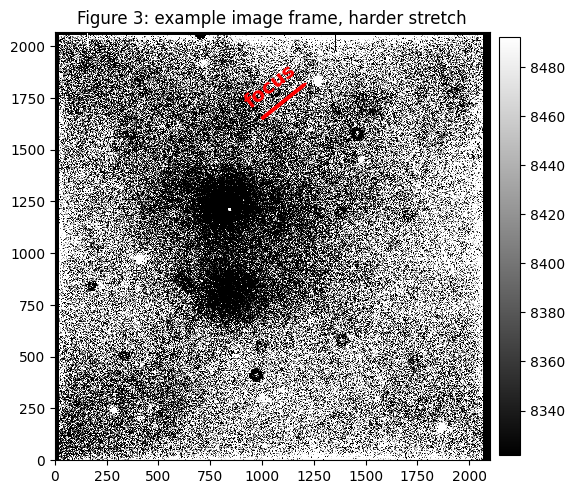

In [4]:
#even harder stretch now.
ns = 0.05

plt.figure( figsize = (6, 6) ) # figure 3
d3 = plt.imshow( flat_data, interpolation='none', origin='lower', 
           vmin=quickmn-ns*quicksg, vmax=quickmn+ns*quicksg, 
           cmap='gray')
plt.colorbar( d3,fraction=0.045, pad=0.02 )


#notice the star upper middle area:
plt.arrow(1000, 1650, 200, 160, color = 'red', head_width = 12,
          shape = 'full' ,width = 12)
plt.text( 900, 1700, 'focus', rotation = 38, 
         fontsize = 14, weight = 'bold', color = 'red' )

dm = plt.title("Figure 3: example image frame, harder stretch")



#### Let's zoom in on star ( x in 1220-1320; y in 1770-1870) , and rescale so that you see it. What happens here? Why is it not a point source?

In [ ]:
# ZOOM in
# Oversaturation

### It's a saturated star! Too many photons into those pixels, so the electrons spilled over into neighboring pixels. 

### The art of making the Calibration Frames: 

- Sensitive analyses and quirky instruments $\rightarrow$ more robust methods

<br>

- Basic principles
    - **Bias frame**: average many 0-exposure images, 
	$$B=\frac{1}{N}\sum{B_{i}}$$
    
    <br>
    - **Dark frame**: 
    
	$$D=\frac{1}{t_{\rm tot}}\sum{(D_{i}-B)}= \frac{1}{t_{\rm tot}}\sum{(D_{i})} - \frac{NB}{t_{\rm tot}}$$
      - $t_{\rm tot}$ is total integration time
      - Average many unlit images with your exposure time
      - ...or take long exposures, subtract mean bias, sum, divide by total itime
      - ...or take dark frames with varying exposure time
          - fit line to image values for each pixel position
          - find bias (intercept) and dark rate (slope)
      - Can then reconstruct dark current for range of exposure times
      - Beware of big extrapolations: best to avoid if possible
      - Dark current is usually very small in the visible
       <br>
      
   
   - **Flat field**: $$F=\frac{\sum{(F_{i}-B-D)}}{{\langle \sum{(F_{i}-B-D)}\rangle}_{\rm pixels}}$$

      - Take many images of uniformly-lit, defocussed subject, half-well
        - Half-well means expose long enough to fill wells (pixels) halfway to saturation
      - Subtract dark and bias
      - Average or median-combine images to get one average image
      - Normalize it so mean value ~1
    - Remaining instrument systematics are consistency problems
    - For consistency problems, take flats/biases through night and use only those nearest in time to exposure.
    - Need flats in each filter!
    
    
- Remember, this procedure is valid for ground-based observations!

#### Side note: the calibration of your dataset will involve many more steps until you eventually reach the final science frames including (but not limited to):
- observation of standard stars and field reference stars 
- tellurics removal
- airmass changes 
- variability
- color correction 
- apperture correction 

#### We will progressively see these in the following classses

### 2. In class assignment: we will work on cleaning up data to get the final science data. 
- A) Get data from files:ICA_Clean_Dat-targets.tar.gz, ICA_Clean_Dat-flats.tar.gz and ICA_Clean_Dat-biases.tar.gz
- B) Unzip and untar those three files. This should result in directories called "biases", "flats", and "targets" that contain the data we will work with. The raw data files are in "targets". The files with the bias frames are in "biases". The files with flats are in "flats". We will revisit this ICA later on, so you can chose if you want to put them in this week's folder, or one layer above.

- C) Read in all 11 of the bias frames into Python so that you have a $11\times2068\times2100$ 3D array, i.e. a data cube.
- D) Start by checking that none of the biases are somehow corrupted, non-standard, or otherwise unhelpful. 
    - Visually inspect each bias to confirm whether each looks like a fairly uniform noise pattern. 
    - If you use imshow() make sure you use some appropriate scaling with [vmin and vmax](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) so you can see the structure in the file

- Let us get some quantitative characterization of the biases. We'll do this by calculating some numbers in a sampling of regions around each frame, as a consistency check. This will let us look for any obvious problems, since each bias should more-or-less be statistically identical. For each bias frame, calculate the median and the standard deviation of all the pixels in each of 4 regions: Region I with pixel range [300:700,300:700], Region II with pixel range [300:700,1300:1700], Region III with pixel range [1300:1700,300:700], and Region IV with pixel range [1300:1700,1300:1700]. So your output should be 88 numbers, 8 for each of the 11 frames, with 4 medians and 4 standard deviations. Use the appropriate print statements to display the output in a tabular way, e.g. something like:

| Region I  | Region II |  Region III |  Region IV |
| --- | --- | --- | --- |
|bias 9 |xxx xxx| xxx xxx|xxx  xxx |xxx xxx|
|bias 10|  xxx xxx   |  xxx xxx  |   xxx  xxx  |   xxx xxx|
 bias N|  ....  | ....|  .... |
 
- E) You should notice from Parts C or D that one of the biases is very much not like the rest. It seems to have suffered perhaps a light leak. Since we have 10 other good frames, we can throw that one irregular one out. So going forward, we will only use these remaining 10. Let us now assess the noise in the bias level. <br> You may have noticed that the standard deviations in problem D are not all identical. This is due to the numerous "hot" (high ADU value) pixels that appear sprinkled around in every bias frame. These are not high-dark current pixels; these are pixels that may have been hit by cosmic rays or that just happen to have weird responses that give them a higher bias level. The standard deviation can be strongly affected by these outliers, so an assessment of the noise in the bias would require removing them. You can use sigma clipping for that (try 3$\sigma$ at 5 iterations). <br>[An alternate method is to fit a Gaussian to the main part of the histogram and extract the $\sigma$ from that fit. So, make that fit on each of the 4 regions in each of the 10 frames. Your output should thus be 40 numbers, and you should then find that the bias level of a given pixel (except for the hot ones) is $\sim 342\pm8$ (almost) everywhere.] Use the appropriate print statements to display the output in a tabular way, e.g. something like:


| Region I  | Region II |  Region III |  Region IV |
| --- | --- | --- | --- |
|bias 9 |xxx xxx| xxx xxx|xxx  xxx |xxx xxx|
|bias 10|  xxx xxx   |  xxx xxx  |   xxx  xxx  |   xxx xxx|
 bias N|  ....  | ....|  .... |
 
 
- F) Now we will "median-combine" all the individual biases and thus create a "master bias." For each pixel [i,j], you would need to calculate the median of all 10 numbers in that particular column of the data cube, and then save that info into the [i,j] location of another 2100-by-2068 array; that array is our master bias. The figure below shows schematically what you need to do. <img src="ica_biases_yf.png" width=300> The datacube is 10 layers thick since there are 10 biases, and for the (0,0) pixel, for example, you need to take the median of the 10 numbers in that vertical column. That median gets saved into the (0,0) pixel of the master bias. (Hint: No need to reinvent the wheel! Check [numpy's median](https://numpy.org/doc/stable/reference/generated/numpy.median.html) out. So the coding math should be literally just one line.) <br>Display this master bias (with an appropriate stretch so that you can see what's going on), and save the plot.

- G) Plot a histogram of the master bias, and fit a Gaussian to the main part of it. What is the $\sigma$ of that Gaussian? (Hint: it should be smaller than what you found in Part E, and this is the one big reason we do this whole procedure instead of just using one bias frame. Combining several frames means that we have a much lower noise contribution by the bias, although it tends to lower the noise pretty slowly; it's an approximately-$\sqrt N$ process.)

- H) Write out the master bias into a FITS file.


In [ ]:
# A
# Got the files

# B
# Untarred them and now they have names: biases, targets, flats

In [2]:
# C

# Reading in all the bias frames
import os
bfiles = os.listdir('biases/')
#print(bfiles)

# They have to be an 11 by 2068 by 2100 3D array so mak empty cube
bdata = np.zeros( (11, 2068, 2100))

# Append them all to the data cube
for i in range(len(bfiles)):
    bdata[i, :, :] = fits.getdata('biases/'+ bfiles[i]).data

# there are 11 bias and each is of dimension 2068 by 2100
bdata.shape

(11, 2068, 2100)

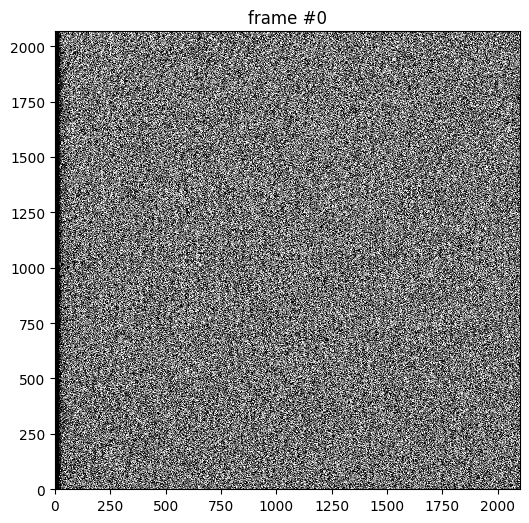

In [3]:
# D

# Visually inspecing the images
quickmn = np.median(bdata)
quicksg = np.std(bdata)
ns = 0.2

# Frame
fr = 0
plt.figure( figsize = (6, 6) )

plt.imshow(bdata[fr, :, :], interpolation='none', origin='lower', 
           vmin=quickmn - ns*quicksg, vmax=quickmn + ns*quicksg, 
           cmap='gray')
plt.title("frame #"+str(fr))
plt.show()

In [4]:
# Looping through

# Region I
x1i, x1f = 300, 700
y1i, y1f = 300, 700

# Region II
x2i, x2f = 300, 700
y2i, y2f = 1300, 1700

# Region II
x3i, x3f = 1300, 1700
y3i, y3f = 300, 700

# Region IV
x4i, x4f = 1300, 1700
y4i, y4f = 1300, 1700

print(" Bias Frame   Region 1        Region 2         Region 3        Region 4       ")
print("-----------------------------------------------------------------------------------")

for i in range(len(bfiles)):
    data1  = bdata[i, (x1i, x1f), (y1i, y1f)]
    data2  = bdata[i, (x2i, x2f), (y2i, y2f)]
    data3  = bdata[i, (x3i, x3f), (y3i, y3f)]
    data4  = bdata[i, (x4i, x4f), (y4i, y4f)]
    mean1  = np.median(data1)
    mean2  = np.median(data2)
    mean3  = np.median(data3)
    mean4  = np.median(data4)
    std1   = np.std(data1)
    std2   = np.std(data2)
    std3   = np.std(data3)
    std4   = np.std(data4)
    print(f"{i}             {mean1}+-{std1}      {mean2}+-{std2}      {mean3}+-{std3}      {mean4}+-{std4}")

 Bias Frame   Region 1        Region 2         Region 3        Region 4       
-----------------------------------------------------------------------------------
0             340.5+-6.5      342.0+-13.0      346.5+-5.5      343.0+-1.0
1             338.5+-2.5      341.0+-2.0      342.5+-2.5      343.0+-8.0
2             347.0+-4.0      342.5+-0.5      335.0+-9.0      346.0+-12.0
3             335.5+-1.5      340.5+-9.5      342.0+-1.0      337.0+-7.0
4             340.5+-6.5      328.5+-2.5      347.5+-5.5      342.0+-2.0
5             356.5+-5.5      364.5+-3.5      371.0+-3.0      384.5+-6.5
6             348.5+-1.5      336.5+-5.5      338.5+-6.5      337.5+-9.5
7             339.0+-2.0      339.0+-4.0      340.0+-3.0      348.0+-5.0
8             347.0+-0.0      348.5+-0.5      349.5+-2.5      350.0+-16.0
9             342.0+-10.0      347.5+-3.5      346.5+-13.5      342.5+-2.5
10             346.0+-8.0      341.0+-2.0      338.0+-0.0      335.5+-2.5


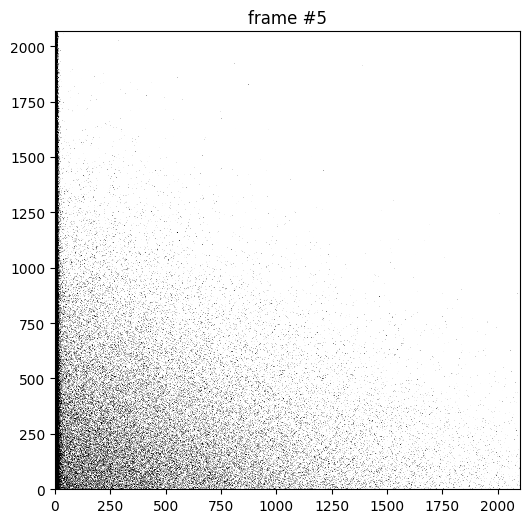

In [5]:
# The one that looks odd is the 5th one

# Visually inspecing the images
quickmn = np.median(bdata)
quicksg = np.std(bdata)
ns = 0.2

# Frame
fr = 5
plt.figure( figsize = (6, 6) )

plt.imshow(bdata[fr, :, :], interpolation='none', origin='lower', 
           vmin=quickmn - ns*quicksg, vmax=quickmn + ns*quicksg, 
           cmap='gray')
plt.title("frame #"+str(fr))
plt.show()

In [17]:
# E

# Sigma clipping
from astropy.stats import sigma_clip

bdata_med = np.append(bdata[0:4, :, :], bdata[5:, :, :], axis=0)

print(" Bias Frame   Region 1        Region 2         Region 3        Region 4       ")
print("-----------------------------------------------------------------------------------")
for i in range(len(bfiles) - 1):
    bdata_med[i, :, :] = sigma_clip(bdata_med[i, :, :], sigma=3, maxiters=5)
    data1  = bdata_med[i, (x1i, x1f), (y1i, y1f)]
    data2  = bdata_med[i, (x2i, x2f), (y2i, y2f)]
    data3  = bdata_med[i, (x3i, x3f), (y3i, y3f)]
    data4  = bdata_med[i, (x4i, x4f), (y4i, y4f)]
    mean1  = np.median(data1)
    mean2  = np.median(data2)
    mean3  = np.median(data3)
    mean4  = np.median(data4)
    std1   = np.std(data1)
    std2   = np.std(data2)
    std3   = np.std(data3)
    std4   = np.std(data4)
    print(f"{i}             {mean1}+-{std1}      {mean2}+-{std2}      {mean3}+-{std3}      {mean4}+-{std4}")



 Bias Frame   Region 1        Region 2         Region 3        Region 4       
-----------------------------------------------------------------------------------
0             340.5+-6.5      342.0+-13.0      346.5+-5.5      343.0+-1.0
1             338.5+-2.5      341.0+-2.0      342.5+-2.5      343.0+-8.0
2             347.0+-4.0      342.5+-0.5      335.0+-9.0      346.0+-12.0
3             335.5+-1.5      340.5+-9.5      342.0+-1.0      337.0+-7.0


IndexError: index 4 is out of bounds for axis 0 with size 4

In [19]:
# F

# Geting the Master median
bias_med = np.median(bdata_med, axis = 0)

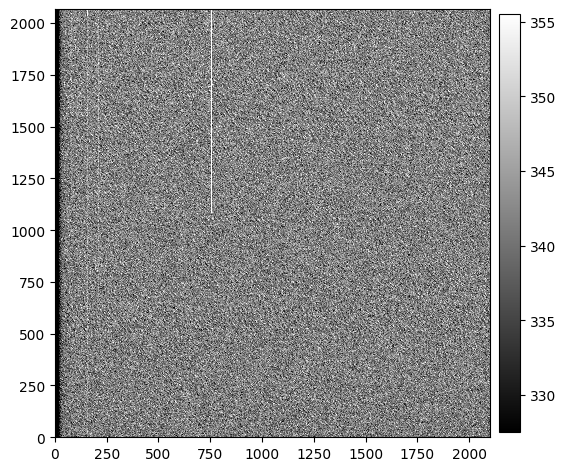

In [20]:
#plot it:
bb = bias_med
quickmn = np.median( bb) 
quicksg = np.std( bb )

ns = 0.2

plt.figure( figsize = (6, 6) ) # figure 2
d2 = plt.imshow( bb, interpolation='none', origin='lower', 
           vmin=quickmn - ns*quicksg, vmax=quickmn + ns*quicksg, 
           cmap='gray')
plt.colorbar( d2,fraction=0.045, pad=0.02 )

In [ ]:
## compare with above...MUCH better!

In [ ]:
# fit gaussian (cp paste from above you will see that sigma went down to 3.54 from 8++)

In [21]:
#write output master:
fits.writeto('biases/master_bias.fits', bias_med)